28


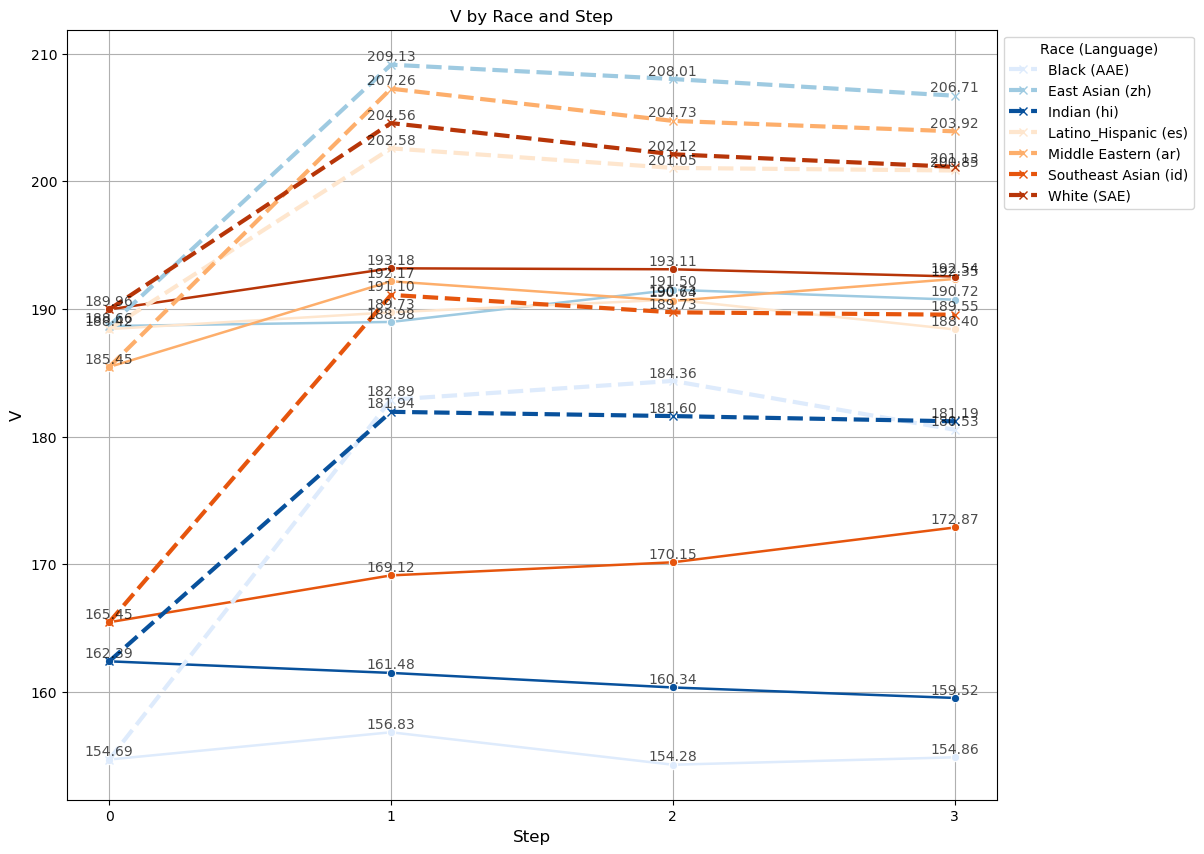

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取第一个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data_1 = pd.read_csv(file_path_1)

# 读取第二个数据文件
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data_2 = pd.read_csv(file_path_2)

# 计算每个递进层次下同一个种族的颜值打分平均值
mean_scores_1 = data_1.groupby(['Step', 'race']).agg({'V': 'mean'}).reset_index()
mean_scores_2 = data_2.groupby(['Step', 'race']).agg({'V': 'mean'}).reset_index()

# 创建种族和语言的对应关系
race_languV_mapping = {
    'White': 'SAE',
    'Black': 'AAE',
    'Middle Eastern': 'ar',
    'Indian': 'hi',
    'Southeast Asian': 'id',
    'Latino_Hispanic': 'es',
    'East Asian': 'zh'
}

# 添加语言列
mean_scores_1['LanguV'] = mean_scores_1['race'].map(race_languV_mapping)
mean_scores_2['LanguV'] = mean_scores_2['race'].map(race_languV_mapping)
cmap = plt.get_cmap('tab20c')
#color = [cmap(i) for i in range(0, 20, 2)][:7]
color = ['#021b7e', '#9fa3ae', '#8fdbfb', '#e6520a', '#ccbae0', '#b3102b', '#9770b6']
color = ['#ece644', '#efab6d', '#7f7db5', '#a5ce9d', '#08519c', '#a2c8dd', ]
color=['#deebfc', '#9ecae1', '#08519c','#fee6ce', '#fdae6b', '#e6550d','#b73508'] 
# 绘图
plt.figure(figsize=(12, 10))

# 绘制第一个数据集
sns.lineplot(data=mean_scores_1, x='Step', y='V', hue='race', marker='o', linestyle='-', palette=color, legend=False,linewidth=1.8)

# 绘制第二个数据集
for race in mean_scores_2['race'].unique():
    subset = mean_scores_2[mean_scores_2['race'] == race]
    plt.plot(subset['Step'], subset['V'], marker='x', linestyle='--', color=sns.color_palette(color)[list(mean_scores_1['race'].unique()).index(race)], label=f"{race} ({subset['LanguV'].iloc[0]})",linewidth=3)

# 添加每个点的数值标签，稍微调整位置
for i in range(len(mean_scores_1)):
    plt.text(mean_scores_1['Step'][i], mean_scores_1['V'][i] + 0.08,
             f"{mean_scores_1['V'][i]:.2f}", 
             fontsize=10, ha='center', va='bottom', alpha=0.7)
print(len(mean_scores_2))
for i in range(7,28):
    plt.text(mean_scores_2['Step'][i], mean_scores_2['V'][i] + 0.08,
             f"{mean_scores_2['V'][i]:.2f}", 
             fontsize=10, ha='center', va='bottom', alpha=0.7)

# 设置图例格式为“种族（语言）”，并将图例移到右侧
plt.legend(title='Race (Language)', loc='upper left', bbox_to_anchor=(1, 1))

plt.title('V by Race and Step')
plt.xlabel('Step',fontsize=12)
plt.ylabel('V',fontsize=12)
plt.xticks([0, 1, 2, 3])  # 确保只显示0, 1, 2, 3
plt.grid()
plt.show()


In [2]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp

# 读取两个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'

data_1 = pd.read_csv(file_path_1)
data_2 = pd.read_csv(file_path_2)

# 定义一个函数，用于对 Step = 0、1、2、3 进行 Kruskal-Wallis H 检验和 Dunn's Test
def perform_tests(data, file_name):
    print(f"\nResults for {file_name}:\n")
    
    # 对每个种族进行 Kruskal-Wallis H 检验
    for race_group in data['race'].unique():
        subset = data[data['race'] == race_group]
        
        # 计算每个步骤的平均数
        mean_values = subset.groupby('Step')['V'].mean().reset_index()
        
        # 保留仅包含 Step 0、1、2、3 的数据
        step_subset = subset[subset['Step'].isin([0, 1, 2, 3])]
        
        if step_subset['Step'].nunique() >= 2:  # 如果有两个或更多 Step
            # 对每对步骤之间进行 Kruskal-Wallis H 检验
            steps = [0, 1, 2, 3]
            for i in range(len(steps)):
                for j in range(i + 1, len(steps)):
                    step_i = steps[i]
                    step_j = steps[j]
                    
                    # 筛选步骤数据
                    step_i_data = step_subset[step_subset['Step'] == step_i]['V']
                    step_j_data = step_subset[step_subset['Step'] == step_j]['V']
                    
                    # 如果两个步骤都有数据，则进行检验
                    if len(step_i_data) > 0 and len(step_j_data) > 0:
                        kruskal_stat, p_value = kruskal(step_i_data, step_j_data)
                        print(f"\nKruskal-Wallis H Test for {race_group} (Step {step_i} vs Step {step_j}):")
                        print(f"H-statistic: {kruskal_stat}, p-value: {p_value}")
                        
                        # 如果有显著性差异，进行 Dunn's Test 事后检验
                        if p_value < 0.05:
                            dunn_test = sp.posthoc_dunn(step_subset, val_col='V', group_col='Step', p_adjust='bonferroni')
                            print(f"\nDunn's Test for {race_group} (Step {step_i} vs Step {step_j}):")
                            print(dunn_test)

# 分别对两个文件进行分析
perform_tests(data_1, "Filter_OpenB.csv")
perform_tests(data_2, "Filter_StabB.csv")



Results for Filter_OpenB.csv:


Kruskal-Wallis H Test for Middle Eastern (Step 1 vs Step 2):
H-statistic: 0.09142857142856542, p-value: 0.7623688184698474

Kruskal-Wallis H Test for Middle Eastern (Step 1 vs Step 3):
H-statistic: 0.02285714285714846, p-value: 0.8798291600118151

Kruskal-Wallis H Test for Middle Eastern (Step 2 vs Step 3):
H-statistic: 0.09142857142856542, p-value: 0.7623688184698474

Kruskal-Wallis H Test for East Asian (Step 1 vs Step 2):
H-statistic: 0.2057142857142793, p-value: 0.6501474440948594

Kruskal-Wallis H Test for East Asian (Step 1 vs Step 3):
H-statistic: 0.09142857142856542, p-value: 0.7623688184698474

Kruskal-Wallis H Test for East Asian (Step 2 vs Step 3):
H-statistic: 0.09142857142856542, p-value: 0.7623688184698474

Kruskal-Wallis H Test for Black (Step 1 vs Step 2):
H-statistic: 0.02285714285714846, p-value: 0.8798291600118151

Kruskal-Wallis H Test for Black (Step 1 vs Step 3):
H-statistic: 0.005714285714276457, p-value: 0.939742989577122

Kruska

In [1]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
'''
    新版
    统计分析：线性混合效应模型
'''
file_path1=r'd:\Users\AAA\Desktop\face++\OpenB.csv'
file_path2=r'd:\Users\AAA\Desktop\face++\StabB.csv'
# 读取数据
df = pd.read_csv(file_path1)
sf = pd.read_csv(file_path2)

jiaocha="+ Language_ar * Step + Language_zh * Step + Language_es * Step + Language_id * Step + Language_hi * Step+ Language_AAE * Step + Gender * Step"
# 定义线性混合效应模型
model = mixedlm("V ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE  + Gender ", 
                df, 
                groups=df["Group"])
# 定义线性混合效应模型
model2 = mixedlm("V ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender ", 
                sf, 
                groups=sf["Group"])
# 拟合模型
result = model.fit()
result2= model2.fit()
# 打印结果
print("OpenArt V",result.summary())
print("StableDiffusion V",result2.summary())

d:\Anaconda3\envs\pytorch\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


OpenArt V            Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  V         
No. Observations:  1540     Method:              REML      
No. Groups:        70       Scale:               54.5899   
Min. group size:   22       Log-Likelihood:      -5480.5839
Max. group size:   22       Converged:           Yes       
Mean group size:   22.0                                    
-----------------------------------------------------------
              Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     177.374    4.728 37.513 0.000 168.106 186.641
Language_ar     5.273    0.679  7.771 0.000   3.943   6.603
Language_zh    -2.268    0.676 -3.355 0.001  -3.593  -0.943
Language_es     1.216    0.675  1.802 0.072  -0.106   2.538
Language_id    -1.760    0.678 -2.595 0.009  -3.089  -0.431
Language_hi     2.774    0.693  4.000 0.000   1.415   4.133
Language_AAE   -0.867    0.675 -1.285 0.1

In [5]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp

# 读取两个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'

data_1 = pd.read_csv(file_path_1)
data_2 = pd.read_csv(file_path_2)

# 定义一个函数，用于对 Step = 0、1、2、3 进行 Kruskal-Wallis H 检验和 Dunn's Test
def perform_tests(data, file_name):
    print(f"\nResults for {file_name}:\n")
    
    # 对每个种族进行 Kruskal-Wallis H 检验
    for race_group in data['race'].unique():
        subset = data[data['race'] == race_group]
        
        # 计算每个步骤的平均数
        mean_values = subset.groupby('Step')['V'].mean().reset_index()
        
        # 保留仅包含 Step 0、1、2、3 的数据
        step_subset = subset[subset['Step'].isin([0, 1, 2, 3])]
        
        if step_subset['Step'].nunique() >= 2:  # 如果有两个或更多 Step
            # 对每对步骤之间进行 Kruskal-Wallis H 检验
            steps = [0, 1, 2, 3]
            for i in range(len(steps)):
                for j in range(i + 1, len(steps)):
                    step_i = steps[i]
                    step_j = steps[j]
                    
                    # 筛选步骤数据
                    step_i_data = step_subset[step_subset['Step'] == step_i]['V']
                    step_j_data = step_subset[step_subset['Step'] == step_j]['V']
                    
                    # 如果两个步骤都有数据，则进行检验
                    if len(step_i_data) > 0 and len(step_j_data) > 0:
                        kruskal_stat, p_value = kruskal(step_i_data, step_j_data)
                        print(f"\nKruskal-Wallis H Test for {race_group} (Step {step_i} vs Step {step_j}):")
                        print(f"H-statistic: {kruskal_stat}, p-value: {p_value}")
                        
                        # 如果有显著性差异，进行 Dunn's Test 事后检验
                        if p_value < 0.05:
                            dunn_test = sp.posthoc_dunn(step_subset, val_col='V', group_col='Step', p_adjust='bonferroni')
                            print(f"\nDunn's Test for {race_group} (Step {step_i} vs Step {step_j}):")
                            print(dunn_test)

# 分别对两个文件进行分析
perform_tests(data_1, "Filter_OpenB.csv")
perform_tests(data_2, "Filter_StabB.csv")



Results for Filter_OpenB.csv:


Kruskal-Wallis H Test for Middle Eastern (Step 0 vs Step 1):
H-statistic: 1.462857142857132, p-value: 0.22647606604348455

Kruskal-Wallis H Test for Middle Eastern (Step 0 vs Step 2):
H-statistic: 0.9657142857142915, p-value: 0.32575135447871234

Kruskal-Wallis H Test for Middle Eastern (Step 0 vs Step 3):
H-statistic: 1.462857142857132, p-value: 0.22647606604348455

Kruskal-Wallis H Test for Middle Eastern (Step 1 vs Step 2):
H-statistic: 0.09142857142856542, p-value: 0.7623688184698474

Kruskal-Wallis H Test for Middle Eastern (Step 1 vs Step 3):
H-statistic: 0.02285714285714846, p-value: 0.8798291600118151

Kruskal-Wallis H Test for Middle Eastern (Step 2 vs Step 3):
H-statistic: 0.09142857142856542, p-value: 0.7623688184698474

Kruskal-Wallis H Test for East Asian (Step 0 vs Step 1):
H-statistic: 0.02285714285714846, p-value: 0.8798291600118151

Kruskal-Wallis H Test for East Asian (Step 0 vs Step 2):
H-statistic: 0.02285714285714846, p-value: 0.879

                         V                                              \
                     count       mean        std       min         25%   
race            Step                                                     
Black           0     10.0  154.69175  34.445035  102.1300  132.757500   
                1     10.0  156.82675  37.148270   98.7175  134.745000   
                2     10.0  154.28500  34.436601   99.0850  134.555625   
                3     10.0  154.86475  32.920394   98.8300  137.045000   
East Asian      0     10.0  188.65950  34.706450  112.2500  175.582500   
                1     10.0  188.97975  33.880874  114.1025  173.803125   
                2     10.0  191.49950  32.012341  122.0725  176.598750   
                3     10.0  190.72325  30.848825  125.6075  174.596875   
Indian          0     10.0  162.38650  39.633251   97.8000  140.063750   
                1     10.0  161.47950  42.209917   97.7775  125.868750   
                2     10.0  160.33775 

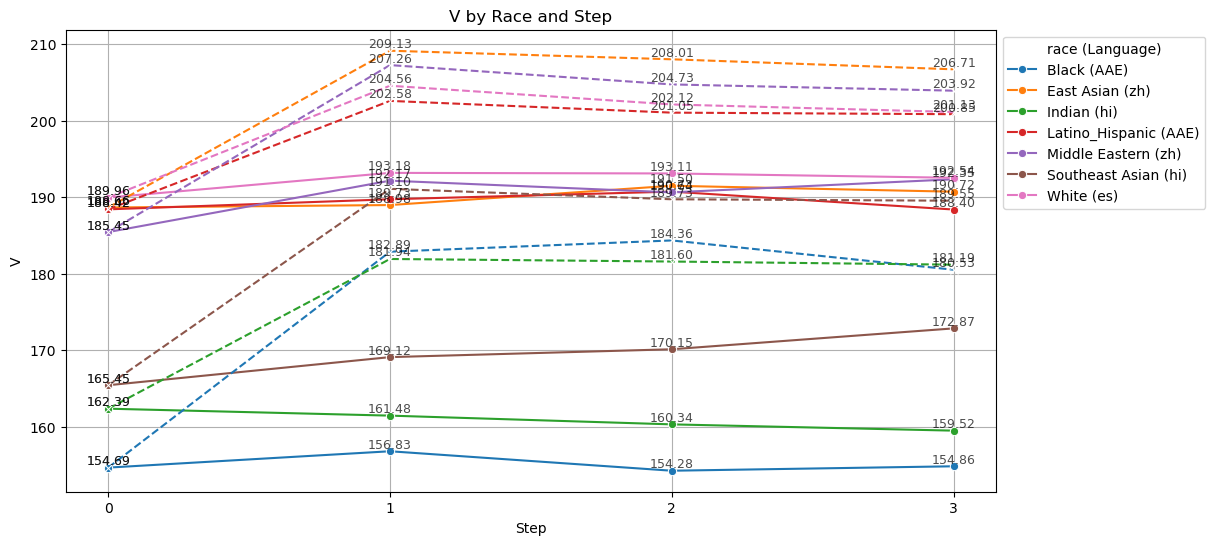

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
'''
    OA/SD
'''
# 读取第一个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data_1 = pd.read_csv(file_path_1)

# 读取第二个数据文件
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data_2 = pd.read_csv(file_path_2)

# 描述性统计，按种族和递进步骤分类
description_1 = data_1.groupby(['race', 'Step'])[['V']].describe()
description_2 = data_2.groupby(['race', 'Step'])[['V']].describe()
print(description_1)
print(description_2)

# 计算每个递进层次下同一个种族的颜值打分平均值
mean_scores_1 = data_1.groupby(['Step', 'race']).agg({
    'V': 'mean',
}).reset_index()

mean_scores_2 = data_2.groupby(['Step', 'race']).agg({
    'V': 'mean',
}).reset_index()

# 创建种族和语言的对应关系
race_languV_mapping = {
    'Middle Eastern': 'ar',
    'White': 'SAE',
    'Black': 'AAE',
    'East Asian': 'zh',
    'Indian': 'hi',
    'Southeast Asian': 'id',
    'Latino_Hispanic': 'es'
}

# 添加语言列
mean_scores_1['Language'] = mean_scores_1['race'].map(race_language_mapping)
mean_scores_2['Language'] = mean_scores_2['race'].map(race_language_mapping)

# 绘图
plt.figure(figsize=(12, 6))

# 绘制第一个数据集
sns.lineplot(data=mean_scores_1, x='Step', y='V', hue='race', marker='o', linestyle='-', palette='tab10')

# 绘制第二个数据集
sns.lineplot(data=mean_scores_2, x='Step', y='V', hue='race', marker='x', linestyle='--', palette='tab10', legend=False)

# 添加每个点的数值标签，稍微调整位置
for i in range(len(mean_scores_1)):
    plt.text(mean_scores_1['Step'][i], mean_scores_1['V'][i] + 0.02,
             f"{mean_scores_1['V'][i]:.2f}", 
             fontsize=9, ha='center', va='bottom', alpha=0.7)

for i in range(len(mean_scores_2)):
    plt.text(mean_scores_2['Step'][i], mean_scores_2['V'][i] + 0.02,
             f"{mean_scores_2['V'][i]:.2f}", 
             fontsize=9, ha='center', va='bottom', alpha=0.7)

# 设置图例格式为“种族（语言）”，并将图例移到右侧
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, [f"{labels[i]} ({mean_scores_1['Language'][i]})" for i in range(len(labels)//2)] +
                     [f"{labels[i]} ({mean_scores_2['Language'][i - len(labels)//2]})" for i in range(len(labels)//2, len(labels))], 
           title='race (Language)', loc='upper left', bbox_to_anchor=(1, 1))

plt.title('V by Race and Step')
plt.xlabel('Step')
plt.ylabel('V')
plt.xticks([0, 1, 2, 3])  # 确保只显示0, 1, 2, 3
plt.grid()
plt.show()


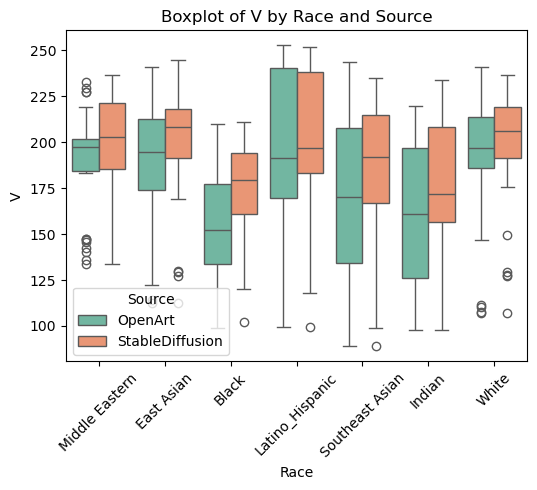

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 读取两个数据文件
file_path1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
file_path2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'

data1 = pd.read_csv(file_path1)
data2 = pd.read_csv(file_path2)

# 为每个数据框添加来源列
data1['Source'] = 'OpenArt'
data2['Source'] = 'StableDiffusion'

# 合并两个数据框
data = pd.concat([data1, data2], ignore_index=True)

# 定义要分析的评分列
score_columns = ['V']

# 绘制箱线图
plt.figure(figsize=(15, 5))
for i, score_column in enumerate(score_columns):
    plt.subplot(1, 3, i + 1)  # 创建子图
    sns.boxplot(x='race', y=score_column, hue='Source', data=data, palette="Set2", dodge=True)
    plt.title(f'Boxplot of {score_column} by Race and Source')
    plt.xlabel('Race')
    plt.ylabel(score_column)
    plt.xticks(rotation=45)
    plt.legend(title='Source')

plt.tight_layout()
plt.show()

# 绘制小提琴图
# plt.figure(figsize=(15, 5))
# for i, score_column in enumerate(score_columns):
#     plt.subplot(1, 3, i + 1)  # 创建子图
#     sns.violinplot(x='race', y=score_column, hue='Source', data=data, inner='quartile', palette="Set2", split=True)
#     plt.title(f'Violin Plot of {score_column} by Race and Source')
#     plt.xlabel('Race')
#     plt.ylabel(score_column)
#     plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()


In [5]:
#Open
import pandas as pd
import scipy.stats as stats

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['V']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("Normality Test Results:")
for score_column, result in normality_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足正态分布的假设。")
    else:
        print("  -> 数据不满足正态分布的假设。")

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("\nLevene's Test for Homogeneity of Variances Results:")
for score_column, result in levene_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足方差齐性的假设。")
    else:
        print("  -> 数据不满足方差齐性的假设。")

# 根据正态性和方差齐性检验结果选择检验方法
for score_column in score_columns:
    normality_p = normality_results[score_column]['p-value']
    levene_p = levene_results[score_column]['p-value']

    print(f"\nAnalyzing {score_column}:")
    if normality_p > 0.05 and levene_p > 0.05:
        # 数据满足正态分布和方差齐性，使用 ANOVA
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        f_stat, p_value = stats.f_oneway(*grouped_data)
        print(f"ANOVA Results: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的年龄存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的年龄不存在显著差异。")
    else:
        # 数据不满足正态分布或方差齐性，使用 Kruskal-Wallis H 检验
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        h_stat, p_value = stats.kruskal(*grouped_data)
        print(f"Kruskal-Wallis H Test Results: H-statistic = {h_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的年龄存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的年龄不存在显著差异。")


Normality Test Results:
V: W-statistic = 0.9655, p-value = 0.0000
  -> 数据不满足正态分布的假设。

Levene's Test for Homogeneity of Variances Results:
V: W-statistic = 4.6563, p-value = 0.0002
  -> 数据不满足方差齐性的假设。

Analyzing V:
Kruskal-Wallis H Test Results: H-statistic = 35.7750, p-value = 0.0000
  -> 结果显著，说明不同种族之间的年龄存在差异。


In [7]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['V']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 结果汇总
results_summary = {}
post_hoc_results = []

# 进行Kruskal-Wallis H检验
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    h_stat, p_value = stats.kruskal(*grouped_data)
    results_summary[score_column] = {'Test': 'Kruskal-Wallis H', 'H-statistic': h_stat, 'p-value': p_value}

    if p_value < 0.05:
        # 进行Dunn's检验以确定具体差异
        from scikit_posthocs import posthoc_dunn
        dunn_results = posthoc_dunn(data, val_col=score_column, group_col='race')
        post_hoc_results.append((score_column, dunn_results))

# 打印结果汇总
results_df = pd.DataFrame(results_summary).T
print("\nStatistical Test Results Summary:")
print(results_df)

# 打印Dunn's检验结果
for score_column, dunn_results in post_hoc_results:
    print(f"\nDunn's Test Results for {score_column}:")
    print(dunn_results)

# 效应量计算
def eta_squared(anova_table):
    """计算Eta squared效应量"""
    return anova_table['sum_sq'][0] / (anova_table['sum_sq'][0] + anova_table['sum_sq'][1])

# 效应量计算
effect_sizes = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    n_total = len(data[score_column])
    n_groups = len(grouped_data)

    # 计算H-statistic
    h_stat, _ = stats.kruskal(*grouped_data)

    # 计算Eta squared
    eta_sq = h_stat / (n_total - 1)
    effect_sizes[score_column] = eta_sq

# 效应量结果
effect_sizes_df = pd.DataFrame(effect_sizes, index=["Eta squared"])
print("\nEffect Sizes Summary:")
print(effect_sizes_df)



Statistical Test Results Summary:
  H-statistic              Test   p-value
V    35.77504  Kruskal-Wallis H  0.000003

Dunn's Test Results for V:
                    Black  East Asian    Indian  Latino_Hispanic  \
Black            1.000000    0.000161  0.441849         0.000196   
East Asian       0.000161    1.000000  0.002660         0.960356   
Indian           0.441849    0.002660  1.000000         0.003129   
Latino_Hispanic  0.000196    0.960356  0.003129         1.000000   
Middle Eastern   0.000112    0.929584  0.001982         0.890182   
Southeast Asian  0.083125    0.041277  0.335166         0.046477   
White            0.000019    0.619141  0.000463         0.584533   

                 Middle Eastern  Southeast Asian     White  
Black                  0.000112         0.083125  0.000019  
East Asian             0.929584         0.041277  0.619141  
Indian                 0.001982         0.335166  0.000463  
Latino_Hispanic        0.890182         0.046477  0.584533  
Mid

In [6]:
#Stab
import pandas as pd
import scipy.stats as stats

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['V']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("Normality Test Results:")
for score_column, result in normality_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足正态分布的假设。")
    else:
        print("  -> 数据不满足正态分布的假设。")

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("\nLevene's Test for Homogeneity of Variances Results:")
for score_column, result in levene_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足方差齐性的假设。")
    else:
        print("  -> 数据不满足方差齐性的假设。")

# 根据正态性和方差齐性检验结果选择检验方法
for score_column in score_columns:
    normality_p = normality_results[score_column]['p-value']
    levene_p = levene_results[score_column]['p-value']

    print(f"\nAnalyzing {score_column}:")
    if normality_p > 0.05 and levene_p > 0.05:
        # 数据满足正态分布和方差齐性，使用 ANOVA
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        f_stat, p_value = stats.f_oneway(*grouped_data)
        print(f"ANOVA Results: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的年龄存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的年龄不存在显著差异。")
    else:
        # 数据不满足正态分布或方差齐性，使用 Kruskal-Wallis H 检验
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        h_stat, p_value = stats.kruskal(*grouped_data)
        print(f"Kruskal-Wallis H Test Results: H-statistic = {h_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的年龄存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的年龄不存在显著差异。")


Normality Test Results:
V: W-statistic = 0.9606, p-value = 0.0000
  -> 数据不满足正态分布的假设。

Levene's Test for Homogeneity of Variances Results:
V: W-statistic = 1.6061, p-value = 0.1454
  -> 数据满足方差齐性的假设。

Analyzing V:
Kruskal-Wallis H Test Results: H-statistic = 36.3440, p-value = 0.0000
  -> 结果显著，说明不同种族之间的年龄存在差异。


In [9]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['V']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 结果汇总
results_summary = {}
post_hoc_results = []

# 进行Kruskal-Wallis H检验
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    h_stat, p_value = stats.kruskal(*grouped_data)
    results_summary[score_column] = {'Test': 'Kruskal-Wallis H', 'H-statistic': h_stat, 'p-value': p_value}

    if p_value < 0.05:
        # 进行Dunn's检验以确定具体差异
        from scikit_posthocs import posthoc_dunn
        dunn_results = posthoc_dunn(data, val_col=score_column, group_col='race')
        post_hoc_results.append((score_column, dunn_results))

# 打印结果汇总
results_df = pd.DataFrame(results_summary).T
print("\nStatistical Test Results Summary:")
print(results_df)

# 打印Dunn's检验结果
for score_column, dunn_results in post_hoc_results:
    print(f"\nDunn's Test Results for {score_column}:")
    print(dunn_results)

# 效应量计算
def eta_squared(anova_table):
    """计算Eta squared效应量"""
    return anova_table['sum_sq'][0] / (anova_table['sum_sq'][0] + anova_table['sum_sq'][1])

# 效应量计算
effect_sizes = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    n_total = len(data[score_column])
    n_groups = len(grouped_data)

    # 计算H-statistic
    h_stat, _ = stats.kruskal(*grouped_data)

    # 计算Eta squared
    eta_sq = h_stat / (n_total - 1)
    effect_sizes[score_column] = eta_sq

# 效应量结果
effect_sizes_df = pd.DataFrame(effect_sizes, index=["Eta squared"])
print("\nEffect Sizes Summary:")
print(effect_sizes_df)



Statistical Test Results Summary:
  H-statistic              Test   p-value
V   36.343998  Kruskal-Wallis H  0.000002

Dunn's Test Results for V:
                    Black  East Asian    Indian  Latino_Hispanic  \
Black            1.000000    0.000014  0.658606         0.001006   
East Asian       0.000014    1.000000  0.000092         0.288016   
Indian           0.658606    0.000092  1.000000         0.004412   
Latino_Hispanic  0.001006    0.288016  0.004412         1.000000   
Middle Eastern   0.000245    0.494311  0.001255         0.704677   
Southeast Asian  0.057446    0.014226  0.144822         0.164824   
White            0.000103    0.639239  0.000580         0.552699   

                 Middle Eastern  Southeast Asian     White  
Black                  0.000245         0.057446  0.000103  
East Asian             0.494311         0.014226  0.639239  
Indian                 0.001255         0.144822  0.000580  
Latino_Hispanic        0.704677         0.164824  0.552699  
Mid

d:\Anaconda3\envs\pytorch\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


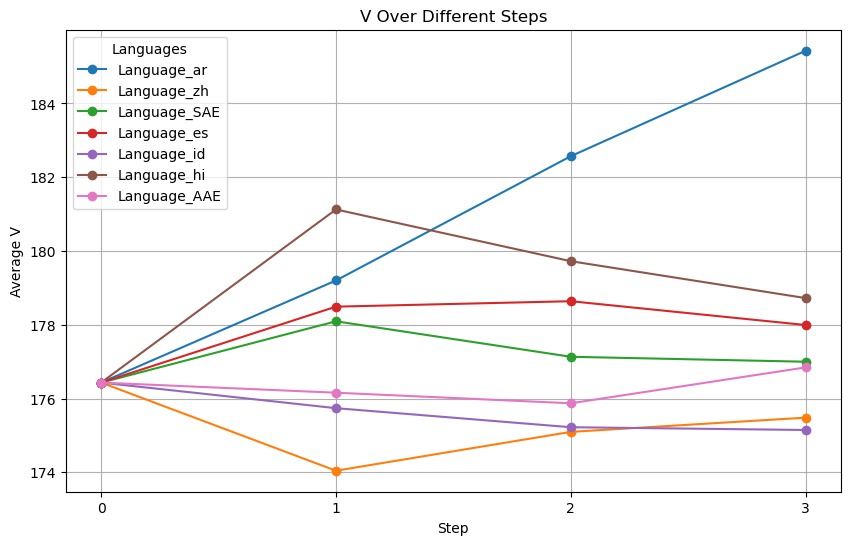

   Language_ar  Language_zh  Language_SAE  Language_es  Language_id  \
0   176.431536   176.431536    176.431536   176.431536   176.431536   
1   179.200143   174.042393    178.093143   178.489929   175.738071   
2   182.569357   175.095464    177.131250   178.637536   175.221536   
3   185.428321   175.481179    176.997071   177.992143   175.146607   

   Language_hi  Language_AAE  
0   176.431536    176.431536  
1   181.125500    176.157429  
2   179.722214    175.870786  
3   178.722321    176.843643  


In [1]:
'''统计分析'''

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
file_path = r'd:\Users\AAA\Desktop\face++\OpenB.csv'  # 替换为实际路径
df = pd.read_csv(file_path)

languages = ['Language_ar', 'Language_zh', 'Language_SAE', 'Language_es', 'Language_id', 'Language_hi', 'Language_AAE']

# 创建空的DataFrame来存储结果
results = {lang: [] for lang in languages}

# 循环每个语言，分别计算每个递进层次的瘦削比平均值
for step in range(4):  # 遍历0, 1, 2, 3步
    for lang in languages:
        # 过滤出该语言且递进层次为step的数据
        if step == 0:
            # 递进层次为0的图像，所有语言共享相同的原图
            filtered_data = df[df['Step'] == 0]
        else:
            # 递进层次不为0时，只筛选特定语言的数据
            filtered_data = df[(df[lang] == 1) & (df['Step'] == step)]
        
        # 计算瘦削比的平均值
        mean_slimness = filtered_data['V'].mean()
        results[lang].append(mean_slimness)

# 转换结果为DataFrame
result_df = pd.DataFrame(results, index=[0, 1, 2, 3])

# 可视化结果
plt.figure(figsize=(10, 6))
for lang in languages:
    plt.plot(result_df.index, result_df[lang], marker='o', label=lang)

plt.title('V Over Different Steps')
plt.xlabel('Step')
plt.ylabel('Average V')
plt.xticks([0, 1, 2, 3])
plt.legend(title='Languages')
plt.grid(True)
plt.show()

# 输出结果表格
print(result_df)


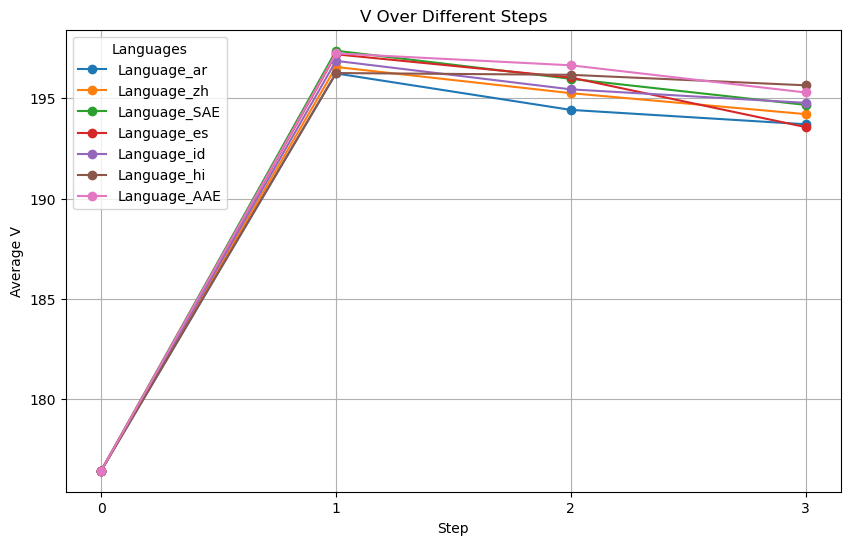

   Language_ar  Language_zh  Language_SAE  Language_es  Language_id  \
0   176.431536   176.431536    176.431536   176.431536   176.431536   
1   196.241821   196.564179    197.374250   197.195964   196.868857   
2   194.423679   195.257286    195.972893   196.039250   195.448000   
3   193.707321   194.213107    194.671893   193.565750   194.775464   

   Language_hi  Language_AAE  
0   176.431536    176.431536  
1   196.261750    197.240857  
2   196.173071    196.647250  
3   195.649464    195.291321  


In [2]:
'''统计分析'''

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
file_path = r'd:\Users\AAA\Desktop\face++\StabB.csv'  # 替换为实际路径
df = pd.read_csv(file_path)

languages = ['Language_ar', 'Language_zh', 'Language_SAE', 'Language_es', 'Language_id', 'Language_hi', 'Language_AAE']

# 创建空的DataFrame来存储结果
results = {lang: [] for lang in languages}

# 循环每个语言，分别计算每个递进层次的瘦削比平均值
for step in range(4):  # 遍历0, 1, 2, 3步
    for lang in languages:
        # 过滤出该语言且递进层次为step的数据
        if step == 0:
            # 递进层次为0的图像，所有语言共享相同的原图
            filtered_data = df[df['Step'] == 0]
        else:
            # 递进层次不为0时，只筛选特定语言的数据
            filtered_data = df[(df[lang] == 1) & (df['Step'] == step)]
        
        # 计算瘦削比的平均值
        mean_slimness = filtered_data['V'].mean()
        results[lang].append(mean_slimness)

# 转换结果为DataFrame
result_df = pd.DataFrame(results, index=[0, 1, 2, 3])

# 可视化结果
plt.figure(figsize=(10, 6))
for lang in languages:
    plt.plot(result_df.index, result_df[lang], marker='o', label=lang)

plt.title('V Over Different Steps')
plt.xlabel('Step')
plt.ylabel('Average V')
plt.xticks([0, 1, 2, 3])
plt.legend(title='Languages')
plt.grid(True)
plt.show()

# 输出结果表格
print(result_df)


In [ ]:
'''加入h\s\v'''

In [ ]:
'''5.17 oa sd公用
主要修改和功能说明：
    标记图像保存路径：

    新增 mark_image_path 变量指定保存路径

    自动创建目录 os.makedirs(mark_image_path, exist_ok=True),所有标记图像都保存到这个统一目录

图像查找逻辑：

    新增 find_image_file 函数专门处理图像查找

    支持图像命名格式：open[数字编号]_[语言编号][递进编号].jpg

    语言编号只接受 sw、id、es 三种
    示例：open1487_sw3.jpg 会在 test/sw/ 子目录下查找
'''


In [4]:
import re
import pandas as pd
import cv2
import numpy as np
import ast
import os
import shutil

# 文件路径配置
file_path = r'd:\Users\AAA\Desktop\517\face++\processed\Processed_Stab.csv'
openb_path = r'D:\Users\AAA\Desktop\face++\StabB.csv'
image_path = r'd:\Users\AAA\Desktop\test'
mark_image_path = r'd:\Users\AAA\Desktop\mark'

# 创建标记图像保存目录
os.makedirs(mark_image_path, exist_ok=True)

# 读取数据
data = pd.read_csv(file_path)
openb_data = pd.read_csv(openb_path)

# 特殊图像编号
special_image_ids = ['264', '818', '908', '3699', '3733', '4215']

# 支持的图像语言类型
valid_languages = ['sw', 'id', 'es']

def extract_skin_color(landmarks_str, image_file, image_name, special_image_ids):
    """提取肤色样本并标记图像"""
    landmarks = ast.literal_eval(landmarks_str)

    # 提取图像编号
    match = re.search(r'stab(\d+)_', image_name)
    image_id = match.group(1) if match else None

    # 确定取样点位置
    if image_id in special_image_ids:
        # 特殊图像使用右眉毛左上方的点
        sample_y = int(landmarks['right_eyebrow_upper_left_quarter']['y'] - 30)
        sample_x = int(landmarks['right_eyebrow_upper_left_quarter']['x'])
    else:
        # 普通图像使用左眉毛右上方的点
        sample_y = int(landmarks['left_eyebrow_upper_right_quarter']['y'] - 30)
        sample_x = int(landmarks['left_eyebrow_upper_right_quarter']['x'])

    image = cv2.imread(image_file)
    if image is None:
        return None, None

    # 标记取样点
    cv2.circle(image, (sample_x, sample_y), 5, (0, 255, 0), -1)  # 绿色圆圈
    # 提取20x20的区域
    sample_region = image[sample_y-10:sample_y+10, sample_x-10:sample_x+10]
    return sample_region, image

def find_image_file(image_name, base_path):
    """根据命名规则查找图像文件"""
    # 解析图像名称
    match = re.match(r'stab(\d+)_([a-z]+)(\d*)\.jpg', image_name.lower())
    if not match:
        return None
    
    num, lang, seq = match.groups()
    if lang not in valid_languages:
        return None
    
    # 构建可能的子文件夹路径
    lang_folder = os.path.join(base_path, lang)
    if not os.path.exists(lang_folder):
        return None
    
    # 查找匹配的图像文件
    for filename in os.listdir(lang_folder):
        if filename.lower() == image_name.lower():
            return os.path.join(lang_folder, filename)
    
    return None

# 初始化HSV列
data['H'] = np.nan
data['S'] = np.nan
data['V'] = np.nan

# 处理每行数据
for idx, row in data.iterrows():
    image_name = row['Image Name']
    found_image = False

    # 查找图像文件
    image_file = find_image_file(image_name, image_path)
    
    if image_file and os.path.isfile(image_file):
        found_image = True
        skin_sample, marked_image = extract_skin_color(row['Landmarks'], image_file, image_name, special_image_ids)
        
        if skin_sample is not None:
            # 计算HSV平均值
            hsv_sample = cv2.cvtColor(skin_sample, cv2.COLOR_BGR2HSV)
            avg_hsv = cv2.mean(hsv_sample)[:3]
            
            # 更新数据
            data.at[idx, 'H'] = avg_hsv[0]
            data.at[idx, 'S'] = avg_hsv[1]
            data.at[idx, 'V'] = avg_hsv[2]

            # 保存标记图像到指定目录
            marked_image_name = f"marked_{image_name}"
            marked_image_file = os.path.join(mark_image_path, marked_image_name)
            cv2.imwrite(marked_image_file, marked_image)

    # 如果在test文件夹中没找到图像，则从OpenB.csv中查找
    if not found_image:
        openb_row = openb_data[openb_data['Image Name'] == image_name]
        if not openb_row.empty:
            # 复制HSV值
            data.at[idx, 'H'] = openb_row.iloc[0]['H']
            data.at[idx, 'S'] = openb_row.iloc[0]['S']
            data.at[idx, 'V'] = openb_row.iloc[0]['V']

# 保存结果
data.to_csv(file_path, index=False)

print("处理完成！结果已保存到原CSV文件中，标记图像已保存到指定目录。")
print(f"共处理 {len(data)} 条数据，其中 {data['H'].notna().sum()} 条有HSV值。")

处理完成！结果已保存到原CSV文件中，标记图像已保存到指定目录。
共处理 1540 条数据，其中 1540 条有HSV值。


In [ ]:
'''BDS版'''

In [33]:
import re
import pandas as pd
import cv2
import numpy as np
import ast
import os
# 读取数据
file_path = r'd:\Users\AAA\Desktop\face++\StabB.csv'
data = pd.read_csv(file_path)

# 获取图像路径和Landmarks列
image_path = r'd:\Users\AAA\Desktop\test'
additional_image_path = r'd:\Users\AAA\Desktop\70'  # 另一个文件夹路径
landmarks_col = data['Landmarks']
image_names = data['Image Name']  # 假设有一列是Image Name

# 特殊图像编号
special_image_ids = ['264', '818', '908', '3699', '3733', '4215']
hsv_colors = []
# 创建一个函数来提取肤色样本
def extract_skin_color(landmarks_str, image_file, image_name, special_image_ids):
    landmarks = ast.literal_eval(landmarks_str)

    # 提取图像编号
    match = re.search(r'stab(\d+)_', image_name)

    if match:
        image_id = match.group(1)
    else:
        image_id = None

    # 检查特定图像编号
    if image_id in special_image_ids:
        # 使用right_eyebrow_upper_left_quarter上方的点
        sample_y = int(landmarks['right_eyebrow_upper_left_quarter']['y'] - 30)
        sample_x = int(landmarks['right_eyebrow_upper_left_quarter']['x'])
    else:
        # 使用left_eyebrow_upper_right_quarter上方30像素的点
        sample_y = int(landmarks['left_eyebrow_upper_right_quarter']['y'] - 30)
        sample_x = int(landmarks['left_eyebrow_upper_right_quarter']['x'])

    image = cv2.imread(image_file)
    if image is None:
        return None, None  # 如果图像未找到，返回None

    # 在图像中标记肤色取样点
    cv2.circle(image, (sample_x, sample_y), 5, (0, 255, 0), -1)  # 绿色圆圈

    # 提取20x20的区域
    sample_region = image[sample_y-10:sample_y+10, sample_x-10:sample_x+10]
    return sample_region, image

# 创建一个函数来提取肤色样本
def v_extract_skin_color(landmarks_str, image_file, image_name, special_image_ids):
    landmarks = ast.literal_eval(landmarks_str)
    match= re.search(r'v_(\d+)',image_name)
    if match:
        image_id = match.group(1)
    else:
        image_id = None

    # 检查特定图像编号
    if image_id in special_image_ids:
        # 使用right_eyebrow_upper_left_quarter上方的点
        sample_y = int(landmarks['right_eyebrow_upper_left_quarter']['y'] - 13.125)
        sample_x = int(landmarks['right_eyebrow_upper_left_quarter']['x'])
    else:
        # 使用left_eyebrow_upper_right_quarter上方40像素的点
        sample_y = int(landmarks['left_eyebrow_upper_right_quarter']['y'] - 13.125)
        sample_x = int(landmarks['left_eyebrow_upper_right_quarter']['x'])

    image = cv2.imread(image_file)
    if image is None:
        return None, None  # 如果图像未找到，返回None

    # 在图像中标记肤色取样点
    cv2.circle(image, (sample_x, sample_y), 5, (0, 255, 0), -1)  # 绿色圆圈

    # 提取10x10的区域
    sample_region = image[sample_y-3:sample_y+3, sample_x-3:sample_x+3]
    return sample_region, image

# 提取肤色样本并分析
for idx, row in data.iterrows():
    image_name = row['Image Name']
    found_image = False

    # 遍历语言编号命名的文件夹
    for lang_folder in os.listdir(image_path):
        lang_folder_path = os.path.join(image_path, lang_folder)
        image_file = os.path.join(lang_folder_path, image_name)

        if os.path.isfile(image_file):  # 检查文件是否存在
            found_image = True
            skin_sample, marked_image = extract_skin_color(row['Landmarks'], image_file, image_name, special_image_ids)
            if skin_sample is not None:
                hsv_sample = cv2.cvtColor(skin_sample, cv2.COLOR_BGR2HSV)
                avg_hsv = cv2.mean(hsv_sample)[:3]  # 获取H, S, V通道的平均值
                hsv_colors.append((image_name, avg_hsv[0], avg_hsv[1], avg_hsv[2]))

                # 保存标记后的图像
                marked_image_file = os.path.join(lang_folder_path, f"marked_{image_name}")
                cv2.imwrite(marked_image_file, marked_image)  # 保存带有肤色取样点标记的图像
            break  # 找到匹配的图像后跳出循环

    # 处理v_格式的图像
    if not found_image:
        v_image_name = f"v_{image_name.split('_')[1]}"  # 从Image Name生成v_格式
        v_image_file = os.path.join(additional_image_path, v_image_name)
        if os.path.isfile(v_image_file):
            skin_sample, marked_image = v_extract_skin_color(row['Landmarks'], v_image_file, v_image_name, special_image_ids)
            if skin_sample is not None:
                hsv_sample = cv2.cvtColor(skin_sample, cv2.COLOR_BGR2HSV)
                avg_hsv = cv2.mean(hsv_sample)[:3]
                hsv_colors.append((v_image_name, avg_hsv[0], avg_hsv[1], avg_hsv[2]))

                # 保存标记后的图像
                marked_image_file = os.path.join(additional_image_path, f"marked_{v_image_name}")
                cv2.imwrite(marked_image_file, marked_image)

# 将结果保存到原始CSV文件中
hsv_results = pd.DataFrame(hsv_colors, columns=['Image Name', 'H', 'S', 'V'])

# 读取原始CSV文件，进行合并
original_data = pd.read_csv(file_path)
merged_data = pd.merge(original_data, hsv_results, on='Image Name', how='left')

# 保存合并后的结果
merged_data.to_csv(file_path, index=False)

print("肤色样本提取和HSV分析完成，结果已保存到原CSV文件中，带标记的图像已保存。")


肤色样本提取和HSV分析完成，结果已保存到原CSV文件中，带标记的图像已保存。
